In [2]:
# Data Analysis Notebook for x_dif Target Variable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display plots inline
%matplotlib inline

# Increase plot resolution for retina displays
%config InlineBackend.figure_format = 'retina'


In [3]:
# Load the data
data_file = '/Users/paulj/Documents/Double_Degree_Tsinghua/Master_thesis/code/my_code/ASTGCN-2019-pytorch/data/3D_datasets/3D_UR5_v3_grid_cleaned.csv'

# Check if the data file exists
if os.path.exists(data_file):
    df = pd.read_csv(data_file)
    print(f"Data loaded from {data_file}")
    print(f"Dataset shape: {df.shape}")
else:
    print(f"Data file {data_file} does not exist. Please check the file path.")


Data loaded from /Users/paulj/Documents/Double_Degree_Tsinghua/Master_thesis/code/my_code/ASTGCN-2019-pytorch/data/3D_datasets/3D_UR5_v3_grid_cleaned.csv
Dataset shape: (1000, 13)


In [4]:
#get rid of first row
df = df.loc[1:]

In [5]:
# Display first few rows
print("First few rows of the dataset:")
df.head()


First few rows of the dataset:


,step_order,x_t,y_t,z_t,x_dif,y_dif,z_dif,joint_1,joint_2,joint_3,joint_4,joint_5,joint_6
1,1,-435.405933,-2.880446,-100.030132,-0.029671,0.820667,-0.153927,-19.715909,-45.884334,127.586736,-71.441952,63.254068,-12.680516
2,2,-468.582105,-3.259530,-99.842232,-0.068946,0.794986,-0.239047,-19.443791,-44.136202,123.031884,-73.825649,55.854319,-0.981410
3,3,-501.876952,-3.834039,-99.108743,-0.173130,0.825600,-0.168906,-18.232226,-39.982615,121.133529,-95.662112,54.932620,5.601158
4,4,-535.499420,-2.603912,-100.057738,-0.012299,0.767448,-0.226668,-14.775595,-41.665835,112.347839,-65.225676,70.945617,1.568907
5,5,-568.701777,-2.393831,-100.617531,0.018079,0.731063,-0.213787,-14.233792,-40.041695,104.120001,-50.607108,68.486202,1.756665


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
step_order    0
x_t           0
y_t           0
z_t           0
x_dif         0
y_dif         0
z_dif         0
joint_1       0
joint_2       0
joint_3       0
joint_4       0
joint_5       0
joint_6       0
dtype: int64


In [7]:
# Handling missing values (if any)
if df.isnull().sum().any():
    print("Handling missing values by dropping rows with missing values.")
    df = df.dropna()
    print(f"New dataset shape after dropping missing values: {df.shape}")
else:
    print("No missing values detected.")


No missing values detected.


In [8]:
# Define target variable and input features
target_variable = 'y_dif'  # Your current target is x deviation
joint_features = [f'joint_{i}' for i in range(1, 7)]
setpoint_features = ['x_set', 'y_set', 'z_set', 'rx_set', 'ry_set', 'rz_set']
input_features = joint_features + setpoint_features

# Ensure all necessary columns are present
required_columns = [target_variable] + input_features
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"The following required columns are missing from the dataset: {missing_columns}")
else:
    print("All required columns are present.")


The following required columns are missing from the dataset: ['x_set', 'y_set', 'z_set', 'rx_set', 'ry_set', 'rz_set']


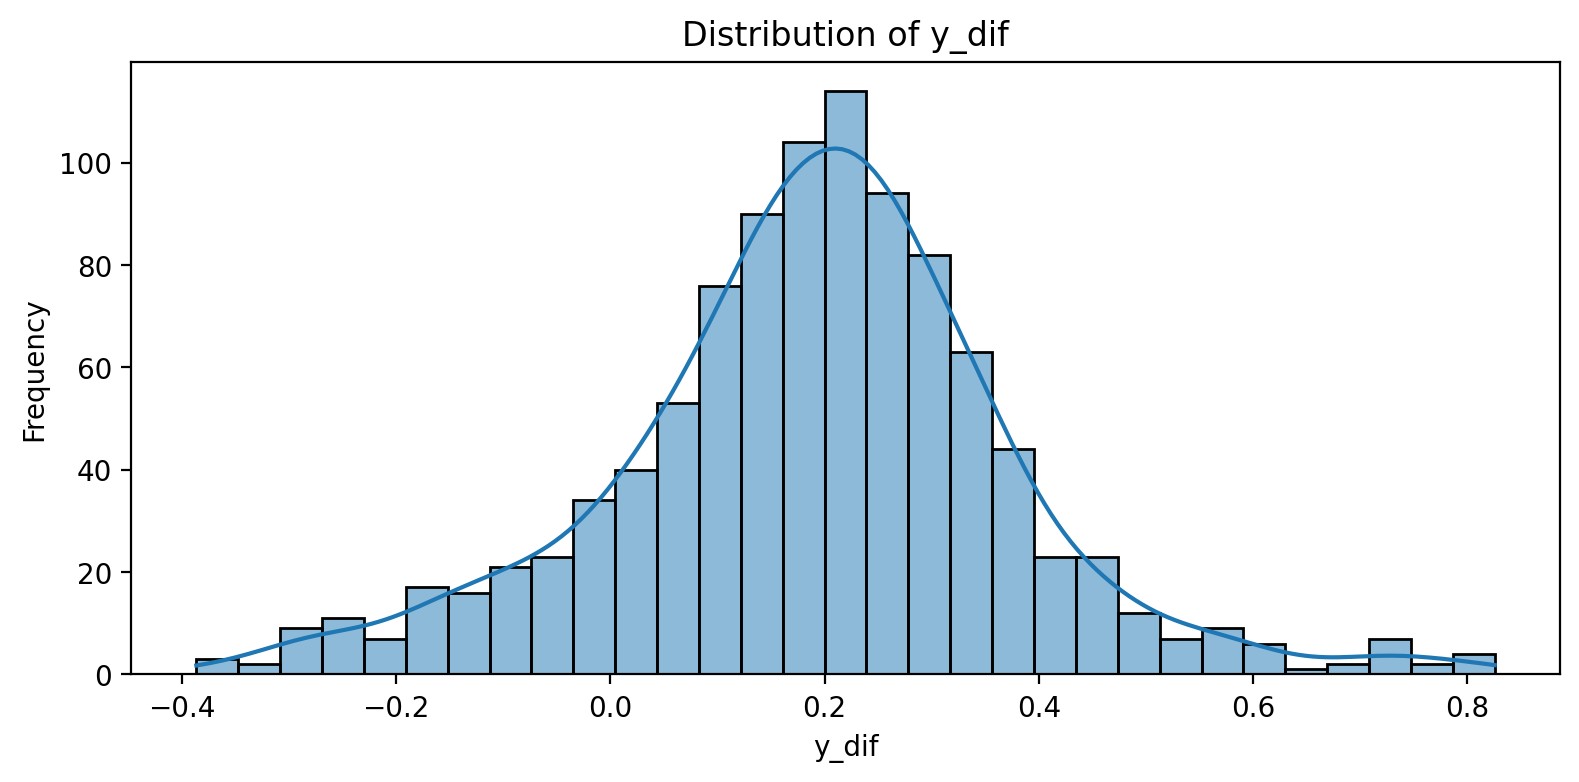

In [9]:
# Visualize distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df[target_variable], kde=True)
plt.title(f"Distribution of {target_variable}")
plt.xlabel(target_variable)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [10]:
# Compute correlations between input features and the target variable
print("Correlation between input features and the target variable:")
corr_matrix = df[input_features + [target_variable]].corr()
corr_with_target = corr_matrix[[target_variable]].loc[input_features]
corr_with_target


Correlation between input features and the target variable:


KeyError: "['x_set', 'y_set', 'z_set', 'rx_set', 'ry_set', 'rz_set'] not in index"

In [ ]:
# Visualize correlations with a bar plot
plt.figure(figsize=(10, 6))
corr_with_target_sorted = corr_with_target.sort_values(by=target_variable, ascending=False)
sns.barplot(x=corr_with_target_sorted.index, y=corr_with_target_sorted[target_variable], palette='viridis')
plt.title(f"Correlation between Input Features and {target_variable}")
plt.xlabel("Input Features")
plt.ylabel(f"Correlation with {target_variable}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Identify features with high correlation to the target variable
threshold = 0.3  # Adjust the threshold based on your needs
high_corr_features = corr_with_target[
    corr_with_target[target_variable].abs() > threshold
]
print(f"Features with correlation |r| > {threshold} with {target_variable}:")
high_corr_features


In [ ]:
# Scatter plots of input features vs. target variable
for feature in input_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=feature, y=target_variable, alpha=0.5)
    plt.title(f"Scatter Plot between {feature} and {target_variable}")
    plt.xlabel(feature)
    plt.ylabel(target_variable)
    plt.tight_layout()
    plt.show()


In [ ]:
# Pairwise correlation among input features
print("Pairwise correlation among input features:")
input_corr_matrix = df[input_features].corr()
input_corr_matrix


In [ ]:
# Visualize input feature correlations with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(input_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Input Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Check for multicollinearity among input features
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Calculating Variance Inflation Factor (VIF) for input features:")

# Prepare data for VIF calculation
X = df[input_features]
X = X.assign(constant=1)  # Add a constant term for intercept

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i) for i in range(len(X.columns))
]

# Remove the constant term from VIF data
vif_data = vif_data[vif_data['Feature'] != 'constant']
vif_data = vif_data.reset_index(drop=True)
vif_data


In [ ]:
# Identify features with high VIF
high_vif = vif_data[vif_data['VIF'] > 5]
print("Features with VIF > 5 (indicating multicollinearity):")
high_vif


In [ ]:
# Box plot to identify outliers in the target variable
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[target_variable])
plt.title(f"Box Plot of {target_variable}")
plt.xlabel(target_variable)
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation and Partial Autocorrelation
plt.figure(figsize=(12, 6))
plot_acf(df[target_variable], lags=50)
plt.title(f"Autocorrelation of {target_variable}")
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(df[target_variable], lags=50)
plt.title(f"Partial Autocorrelation of {target_variable}")
plt.show()


In [ ]:
window_size = 100  # Adjust based on your data size
rolling_mean = df[target_variable].rolling(window=window_size).mean()
rolling_std = df[target_variable].rolling(window=window_size).std()

plt.figure(figsize=(12, 6))
plt.plot(df[target_variable], label='Original')
plt.plot(rolling_mean, label=f'Rolling Mean (window={window_size})', linestyle='--')
plt.plot(rolling_std, label=f'Rolling Std Dev (window={window_size})', linestyle=':')
plt.title(f"Rolling Statistics of {target_variable}")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from scipy import stats

# Fit a normal distribution
mu, std = stats.norm.fit(df[target_variable])

# Plot the histogram and the fitted distribution
plt.figure(figsize=(8, 4))
sns.histplot(df[target_variable], kde=True, stat="density", linewidth=0)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title(f"Fit a Normal Distribution to {target_variable}")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import probplot

probplot(df[target_variable], dist="norm", plot=plt)
plt.title(f"Q-Q Plot of {target_variable} against Normal Distribution")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import zscore

df['z_score'] = zscore(df[target_variable])
outliers = df[df['z_score'].abs() > 3]  # Threshold of 3 for Z-Score
print("Outliers based on Z-Score:")
print(outliers)


In [ ]:
from sklearn.ensemble import IsolationForest

# Fit Isolation Forest model
iso_forest = IsolationForest(contamination=0.05)  # Adjust contamination level
outliers = iso_forest.fit_predict(df[[target_variable]])

# -1 for outliers, 1 for inliers
df['outliers'] = outliers
outliers_df = df[df['outliers'] == -1]
print(f"Number of outliers detected: {len(outliers_df)}")


In [ ]:
skewness = df[target_variable].skew()
kurtosis = df[target_variable].kurtosis()

print(f"Skewness of {target_variable}: {skewness}")
print(f"Kurtosis of {target_variable}: {kurtosis}")


In [ ]:
lag = 1  # 1 step ahead
df['target_lag'] = df[target_variable].shift(lag)

# Correlation with lagged target
lag_corr = df[[target_variable, 'target_lag']].corr()
print(f"Correlation between {target_variable} and its lagged version: {lag_corr}")


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df[target_variable])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
